S(0)  =
[[ 2.41141985 -0.33344122]
 [-0.25847038  1.49744877]]
S(T)  =
[[1. 0.]
 [0. 2.]]
Terminal error ||S(T) - R|| = 0.00e+00
t=0.0, x=[1. 1.], v=3.5610, a=[-1.0389893 -2.2779677]
t=0.5, x=[ 0.5 -0.5], v=1.0594, a=[-0.5207194  0.3403064]
t=1.0, x=[0. 0.], v=0.0000, a=[0. 0.]
Saved exercise_1_1_riccati.png
Saved exercise_1_1_value_function.png
t=1.0: S=
[[1. 0.]
 [0. 2.]]
Symmetry error ||S - S^T|| = 0.00e+00


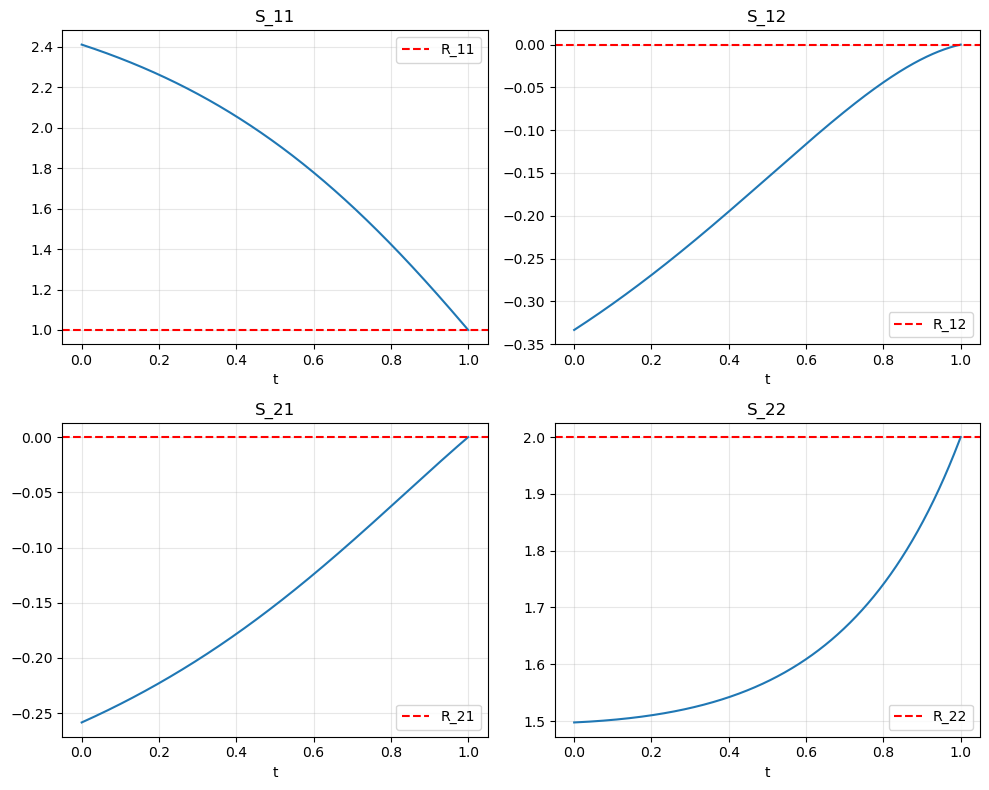

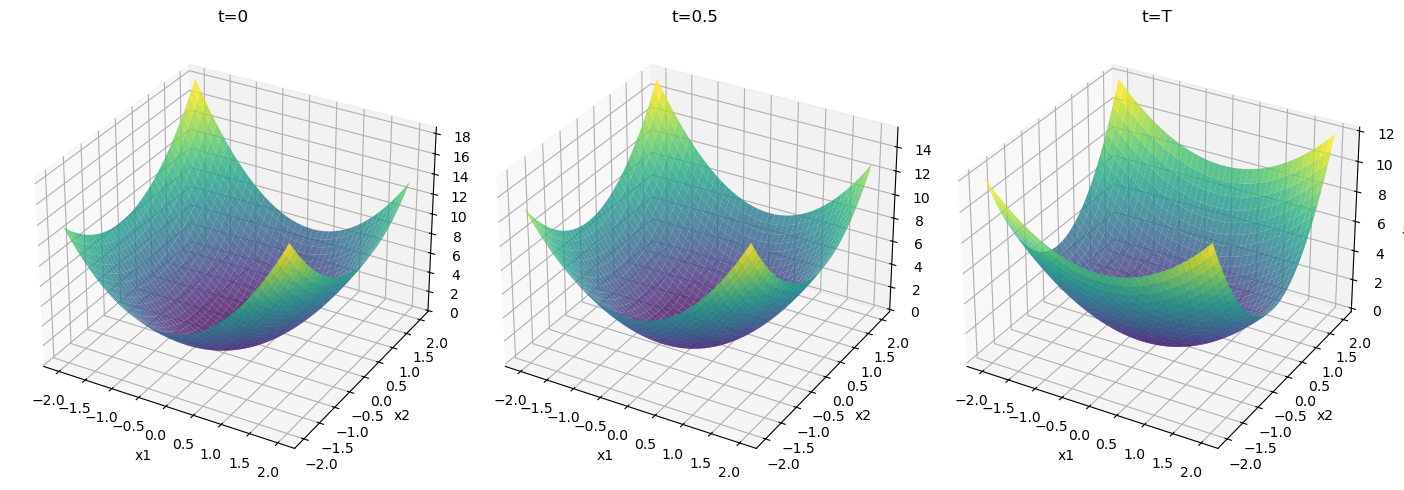

In [7]:
"""
Exercise 1.1 - LQR Solver via Riccati ODE
"""

import numpy as np
import torch
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt


class LQRSolver:
    """
    Solves the LQR problem via Riccati ODE.

    We want to minimise
        J(t,x) = E[ int_t^T (X'CX + a'Da) ds + X_T' R X_T ],
    subject to
        dX = (HX + Ma) dt + sigma dW,  X_t = x.

    The value function is
        v(t,x) = x'S(t)x + int_t^T tr(sigma sigma' S(r)) dr
    where S solves the Riccati ODE and the optimal control is 
        a(t,x) = -D^{-1} M' S(t) x.
    """

    def __init__(self, H, M, C, D, R, sigma, T):
        self.H = np.array(H, dtype=float)
        self.M = np.array(M, dtype=float)
        self.C = np.array(C, dtype=float)
        self.D = np.array(D, dtype=float)
        self.R = np.array(R, dtype=float)
        self.sigma = np.array(sigma, dtype=float)
        self.T = float(T)

        # precompute these since they're used a lot
        self.D_inv = np.linalg.inv(self.D)
        self.MD_invMT = self.M @ self.D_inv @ self.M.T

        self.S_interp = None
        self.integral_interp = None

    def _riccati_rhs(self, tau, S_flat):
        """
        RHS of the Riccati ODE in forward time (tau = T - t).

        The ODE in original time is
            S'(t) = -2H'S + S M D^{-1} M' S - C,   S(T) = R.

        Substituting tau = T - t flips the sign so we can use a standard
        forward solver
            dS/dtau = 2H'S - S M D^{-1} M' S + C.
        """
        S = S_flat.reshape(2, 2)
        dS = 2 * self.H.T @ S - S @ self.MD_invMT @ S + self.C
        return dS.flatten()

    def solve_riccati(self, time_grid):
        """
        Solve the Riccati ODE on the given time grid and build interpolators
        for S(t) and the integral term.

        Args:
            time_grid: array of times in [0, T] (numpy or torch)

        Returns:
            S_values: array of shape (len(time_grid), 2, 2)
        """
        if isinstance(time_grid, torch.Tensor):
            time_grid = time_grid.cpu().numpy()
        time_grid = np.array(time_grid, dtype=float)

        # solve forward in tau = T - t, starting from S(T) = R
        tau_grid = self.T - time_grid  # decreasing in t -> increasing in tau
        sol = solve_ivp(
            self._riccati_rhs,
            (0.0, self.T),
            self.R.flatten(),
            t_eval=tau_grid[::-1],  # need increasing tau values
            method='RK45',
            rtol=1e-8,
            atol=1e-10
        )

        if not sol.success:
            raise RuntimeError(f"Riccati solve failed: {sol.message}")

        # reverse back so columns match increasing t
        S_values = sol.y[:, ::-1].T.reshape(-1, 2, 2)

        # build interpolator for S(t)
        self.S_interp = [
            [interp1d(time_grid, S_values[:, i, j], kind='cubic',
                      bounds_error=False, fill_value='extrapolate')
             for j in range(2)]
            for i in range(2)
        ]

        # compute integral term: int_t^T tr(sigma sigma' S(r)) dr
        # this is the noise-driven part of the value function (doesn't depend on x)
        ss = self.sigma @ self.sigma.T
        trace_vals = np.array([np.trace(ss @ S) for S in S_values])

        # integrate backwards using trapezoid rule
        integral = np.zeros(len(time_grid))
        for i in range(len(time_grid) - 2, -1, -1):
            dt = time_grid[i+1] - time_grid[i]
            integral[i] = integral[i+1] + 0.5 * dt * (trace_vals[i] + trace_vals[i+1])

        self.integral_interp = interp1d(time_grid, integral, kind='cubic',
                                        bounds_error=False, fill_value='extrapolate')

        return S_values

    def _get_S(self, t):
        """Evaluate S(t) at one or more times. Accepts numpy arrays or torch tensors."""
        if self.S_interp is None:
            raise RuntimeError("Call solve_riccati first")

        is_torch = isinstance(t, torch.Tensor)
        t_np = t.cpu().numpy() if is_torch else np.asarray(t, dtype=float)

        shape = t_np.shape
        t_flat = t_np.flatten()

        S_out = np.zeros((len(t_flat), 2, 2))
        for i in range(2):
            for j in range(2):
                S_out[:, i, j] = self.S_interp[i][j](t_flat)

        S_out = S_out.reshape(*shape, 2, 2)

        if is_torch:
            return torch.from_numpy(S_out).float().to(t.device)
        return S_out

    def value_function(self, t_batch, x_batch):
        """
        Compute v(t, x) = x' S(t) x + int_t^T tr(sigma sigma' S(r)) dr.

        Args:
            t_batch: torch tensor, shape (batch_size,)
            x_batch: torch tensor, shape (batch_size, 1, 2)

        Returns:
            v: torch tensor, shape (batch_size, 1)
        """
        if self.S_interp is None:
            raise RuntimeError("Call solve_riccati first")

        S = self._get_S(t_batch)  # (batch, 2, 2)
        x = x_batch.squeeze(1)   # (batch, 2)

        # quadratic form x' S(t) x
        xSx = torch.sum((x.unsqueeze(1) @ S).squeeze(1) * x, dim=1)

        # integral correction (noise term)
        integral_vals = torch.from_numpy(
            self.integral_interp(t_batch.cpu().numpy())
        ).float().to(t_batch.device)

        return (xSx + integral_vals).unsqueeze(1)

    def optimal_control(self, t_batch, x_batch):
        """
        Compute the optimal control a(t, x) = -D^{-1} M' S(t) x.

        Args:
            t_batch: torch tensor, shape (batch_size,)
            x_batch: torch tensor, shape (batch_size, 1, 2)

        Returns:
            a: torch tensor, shape (batch_size, 2)
        """
        if self.S_interp is None:
            raise RuntimeError("Call solve_riccati first")

        S = self._get_S(t_batch)  # (batch, 2, 2)
        x = x_batch.squeeze(1)   # (batch, 2)

        neg_DinvMT = torch.from_numpy(-self.D_inv @ self.M.T).float().to(t_batch.device)

        # compute S(t) x then apply -D^{-1} M'
        Sx = (S @ x.unsqueeze(2)).squeeze(2)           # (batch, 2)
        a = (neg_DinvMT @ Sx.unsqueeze(2)).squeeze(2)  # (batch, 2)

        return a


# --------------------------------------------
# Quick demo / sanity checks
# --------------------------------------------

if __name__ == "__main__":

    # problem matrices (same as coursework spec)
    H = np.array([[0.5, 0.1], [0.1, 0.3]])
    M     = np.array([[1.0, 0.5], [0.0, 1.0]])
    C     = np.array([[2.0, 0.5], [0.5, 1.0]])
    D     = np.array([[2.0, 0.0], [0.0, 1.0]])
    R     = np.array([[1.0, 0.0], [0.0, 2.0]])
    sigma = np.array([[0.3, 0.1], [0.0, 0.2]])
    T     = 1.0

    solver = LQRSolver(H, M, C, D, R, sigma, T)
    time_grid = np.linspace(0, T, 1000)
    S_vals = solver.solve_riccati(time_grid)

    print(f"S(0)  =\n{S_vals[0]}")
    print(f"S(T)  =\n{S_vals[-1]}")
    print(f"Terminal error ||S(T) - R|| = {np.linalg.norm(S_vals[-1] - R):.2e}")

    # check value function and control at a few points
    t_test = torch.tensor([0.0, 0.5, 1.0])
    x_test = torch.tensor([[[1.0, 1.0]], [[0.5, -0.5]], [[0.0, 0.0]]])

    v = solver.value_function(t_test, x_test)
    a = solver.optimal_control(t_test, x_test)
    for i in range(3):
        print(f"t={t_test[i]:.1f}, x={x_test[i,0].numpy()}, v={v[i,0]:.4f}, a={a[i].numpy()}")

    # Plot 1: Riccati solution components 
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    labels = [['S_11', 'S_12'], ['S_21', 'S_22']]
    for i in range(2):
        for j in range(2):
            ax = axes[i, j]
            ax.plot(time_grid, S_vals[:, i, j])
            ax.axhline(R[i, j], color='r', linestyle='--', label=f'R_{i+1}{j+1}')
            ax.set_xlabel('t')
            ax.set_title(labels[i][j])
            ax.legend()
            ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('exercise_1_1_riccati.png', dpi=150, bbox_inches='tight')
    print("Saved exercise_1_1_riccati.png")

    # Plot 2: Value function surface at t=0, 0.5, T 
    fig = plt.figure(figsize=(14, 5))
    x_range = np.linspace(-2, 2, 40)
    X1, X2 = np.meshgrid(x_range, x_range)
    x_grid = torch.stack([torch.tensor(X1).float(),
                          torch.tensor(X2).float()], dim=-1).reshape(-1, 1, 2)

    for idx, (t_val, lbl) in enumerate([(0.0, 't=0'), (0.5, 't=0.5'), (1.0, 't=T')]):
        ax = fig.add_subplot(1, 3, idx+1, projection='3d')
        t_grid = torch.full((X1.size,), t_val)
        V = solver.value_function(t_grid, x_grid).reshape(X1.shape).detach().numpy()
        ax.plot_surface(X1, X2, V, cmap='viridis', alpha=0.8)
        ax.set_xlabel('x1'); ax.set_ylabel('x2')
        ax.set_zlabel(f'v({t_val}, x)')
        ax.set_title(lbl)

    plt.tight_layout()
    plt.savefig('exercise_1_1_value_function.png', dpi=150, bbox_inches='tight')
    print("Saved exercise_1_1_value_function.png")

    for t_check in [0.0, 0.5, 1.0]:
        S = solver._get_S(np.array([t_check]))[0]
    print(f"t={t_check}: S=\n{S}")
    print(f"Symmetry error ||S - S^T|| = {np.linalg.norm(S - S.T):.2e}")